<a href="https://colab.research.google.com/github/edik06031-rgb/Analysis_Cafe_Sales-/blob/main/HW/practice_stat_tests_17_06.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Статистичні тести: практикум

**Тривалість:** ~4 години · бібліотека `scipy.stats`

---

Цей практикум закріплює лекцію про p-значення та статистичну значущість. Він влаштований так:

- 🟦 **Теорія** — короткий блок перед кожним тестом: *коли* його обирати, *чому*, *як читати результат*.
- ✏️ **Завдання (код)** — ви пишете код, що проводить тест.
- 💬 **Інтерпретація** — ви **своїми словами** пояснюєте, що означає результат. Це найважливіша частина! Аналітик, який уміє порахувати p-значення, але не вміє його пояснити — це лише калькулятор.

## Як працювати
1. Читайте теоретичний блок.
2. Виконуйте завдання на код (Shift+Enter).
3. На кожне питання інтерпретації відповідайте **повним реченням людською мовою** — так, ніби пояснюєте керівнику без технічної освіти.

## Загальне правило
- `p < 0.05` → статистично значущо → відхиляємо H₀
- `p ≥ 0.05` → не значущо → не відхиляємо H₀

> 💡 Тримайте поруч шпаргалку вибору тесту з лекції. Половина завдань — про те, щоб **обрати правильний тест**.

---

## Підготовка

Запустіть цю клітинку. Ми працюємо з двома наборами даних:
- **`shop_customers.csv`** — 500 клієнтів інтернет-магазину
- **`ab_test.csv`** — результати A/B-тесту (8000 сесій)


In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

df = pd.read_csv("shop_customers.csv")
ab = pd.read_csv("ab_test.csv")

print("Клієнти:", df.shape)
print("A/B тест:", ab.shape)
df.head()

Клієнти: (500, 11)
A/B тест: (8000, 3)


,customer_id,gender,age,country,channel,device,spend,session_min,sat_before,sat_after,purchased
0,1001,Ч,23,Німеччина,Реклама,Desktop,997.11,22.2,6,7,Так
1,1002,Ч,38,Україна,Органіка,Desktop,510.09,19.8,5,8,Ні
2,1003,Ч,20,Україна,Соцмережі,Desktop,789.71,21.0,7,8,Ні
3,1004,Ч,40,Німеччина,Соцмережі,Desktop,1041.02,17.4,8,9,Ні
4,1005,Ч,18,Україна,Реклама,Desktop,944.34,23.5,6,7,Ні


### Опис даних `shop_customers.csv`

| Стовпець | Опис | Тип |
|---|---|---|
| `customer_id` | ID клієнта | — |
| `gender` | Стать (Ч/Ж) | категоріальний |
| `age` | Вік | числовий |
| `country` | Країна | категоріальний |
| `channel` | Канал залучення (Органіка/Реклама/Соцмережі) | категоріальний |
| `device` | Пристрій (Mobile/Desktop) | категоріальний |
| `spend` | Витрати клієнта, грн | числовий |
| `session_min` | Час на сайті, хв | числовий |
| `sat_before` | Задоволеність ДО редизайну (1-10) | числовий |
| `sat_after` | Задоволеність ПІСЛЯ редизайну (1-10) | числовий |
| `purchased` | Чи зробив покупку (Так/Ні) | категоріальний |

Спочатку завжди корисно роздивитись дані.

#### ✏️ Завдання 1 (код)

Виведіть основну статистику по числових стовпцях (підказка: метод `.describe()`).

In [ ]:
# Завдання 1:
stats = df.describe().round(2)
print(stats)

       customer_id     age    spend  session_min  sat_before  sat_after
count       500.00  500.00   500.00       500.00      500.00     500.00
mean       1250.50   34.65   845.02        20.74        6.54       7.14
std         144.48   10.96   333.46        10.53        1.52       1.83
min        1001.00   18.00    50.00         1.00        2.00       1.00
25%        1125.75   26.00   612.63        13.10        6.00       6.00
50%        1250.50   34.00   834.75        20.85        7.00       7.00
75%        1375.25   41.25  1070.40        27.40        8.00       9.00
max        1500.00   69.00  1952.02        52.20       10.00      10.00


#### ✏️ Завдання 2 (код)

Скільки клієнтів у кожному каналі залучення? (підказка: `.value_counts()` на стовпці `channel`)

In [ ]:
# Завдання 2:
channel_counts = df['channel'].value_counts()

print('Кількість клієнтів по каналах залучення:')
print(channel_counts)

Кількість клієнтів по каналах залучення:
channel
Органіка     174
Соцмережі    167
Реклама      159
Name: count, dtype: int64


---
# Розділ 1. Одновибірковий t-тест

## 🟦 Теорія: коли і чому

**Коли обирати:** коли у вас є **одна** група числових даних, і ви хочете порівняти її **середнє** з якимось **фіксованим, наперед відомим числом** (ціль, норматив, заявлене значення).

**Чому саме він:** ми перевіряємо, чи відхилення нашого середнього від цільового числа реальне, чи це випадковість вибірки.

**Гіпотези:**
- H₀: середнє = цільове число
- H₁: середнє ≠ цільове число

**Функція:** `stats.ttest_1samp(дані, цільове_число)`

**Як читати:** дивимось на p-значення. Якщо `p < 0.05` — середнє значущо відрізняється від цільового.

**Приклад із життя:** виробник заявляє, що пакет чипсів важить 100 г. Ви зважили 50 пакетів. Чи справді середня вага = 100 г, чи вас обманюють?

**Сценарій:** маркетолог стверджує, що середній час на сайті становить 20 хвилин. Перевіримо це.

#### ✏️ Завдання 3 (код)

Порахуйте фактичний середній `session_min`. Потім проведіть одновибірковий t-тест, щоб перевірити, чи відрізняється він від 20. Виведіть t-статистику та p-значення.

In [ ]:
# Завдання 3:
from scipy.stats import ttest_1samp

# Фактичний середній час сесії
mean_session = df['session_min'].mean()

# H0: середній час сесії = 20 хв
t_stat, p_value = ttest_1samp(df['session_min'].dropna(), popmean=20)

print(f'Середній session_min: {mean_session:.2f}')
print(f't-статистика: {t_stat:.4f}')
print(f'p-значення: {p_value:.4f}')

Середній session_min: 20.74
t-статистика: 1.5698
p-значення: 0.1171


#### 💬 Інтерпретація 1

Чи відрізняється середній час на сайті від заявлених 20 хвилин? Сформулюйте висновок для маркетолога: він мав рацію чи ні? Чому ви так вважаєте (спирайтесь на p-значення)?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

*.Було проведено одновибірковий t-тест для перевірки твердження маркетолога, що середній час перебування користувача на сайті становить 20 хвилин.

Фактичний середній час сесії склав 20.74 хвилини, а отримане p-значення = 0.1171.

Оскільки p-value > 0.05, ми не відхиляємо нульову гіпотезу. Це означає, що різниця між фактичним середнім часом (20.74 хв) та заявленими 20 хвилинами не є статистично значущою.

Висновок для маркетолога: наявні дані не дають підстав стверджувати, що середній час перебування на сайті відрізняється від 20 хвилин. Отже, твердження маркетолога узгоджується з даними, і його оцінку можна вважати обґрунтованою...*

**Другий сценарій:** керівник вважає, що середні витрати клієнта = 850 грн.

#### ✏️ Завдання 4 (код)

Перевірте за допомогою одновибіркового t-тесту, чи середні витрати (`spend`) відрізняються від 850 грн.

In [ ]:
# Завдання 4:
from scipy.stats import ttest_1samp

mean_spend = df['spend'].mean()

t_stat, p_value = ttest_1samp(
    df['spend'].dropna(),
    popmean=850
)

print(f'Середні витрати: {mean_spend:.2f}')
print(f't-статистика: {t_stat:.4f}')
print(f'p-значення: {p_value:.4f}')

Середні витрати: 845.02
t-статистика: -0.3342
p-значення: 0.7384


#### 💬 Інтерпретація 2

Що показав тест? Чи можна сказати, що середні витрати дорівнюють 850 грн? Поясніть, чому тут ми НЕ відхиляємо нульову гіпотезу (зверніть увагу на формулювання: чи це означає, що середнє точно дорівнює 850?).

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

*Було проведено одновибірковий t-тест для перевірки твердження керівника, що середні витрати клієнта становлять 850 грн.

Фактичні середні витрати склали 845.02 грн, а отримане p-значення = 0.7384.

Оскільки p-value значно більше 0.05, ми не відхиляємо нульову гіпотезу. Це означає, що різниця між середнім значенням у вибірці (845.02 грн) та 850 грн є статистично незначущою і може бути пояснена випадковими коливаннями даних.

Важливо розуміти, що не відхилити нульову гіпотезу не означає довести, що середні витрати точно дорівнюють 850 грн. Це лише означає, що на основі наявної вибірки немає достатніх статистичних доказів стверджувати, що середні витрати відрізняються від 850 грн.

Отже, дані узгоджуються з припущенням керівника, і твердження про середні витрати на рівні 850 грн можна вважати обґрунтованим.*

---
# Розділ 2. Двовибірковий t-тест (незалежні групи)

## 🟦 Теорія: коли і чому

**Коли обирати:** коли ви порівнюєте **середні двох РІЗНИХ, незалежних груп** числових даних.

**Чому саме він:** хочемо дізнатись, чи різниця між групами реальна, чи могла виникнути випадково.

**Ключова умова — групи НЕЗАЛЕЖНІ:** різні люди в кожній групі (на відміну від парного тесту, де ті самі люди двічі).

**Гіпотези:**
- H₀: середнє групи 1 = середнє групи 2
- H₁: вони відрізняються

**Функція:** `stats.ttest_ind(група1, група2)`

**Приклад із життя:** чи відрізняється середня зарплата у двох відділах? Чи витрачають більше клієнти з міста А порівняно з містом Б?

**Сценарій:** чи витрачають клієнти з мобільних більше, ніж з десктопу?

#### ✏️ Завдання 5 (код)

Розділіть `spend` на дві групи за `device` (Mobile та Desktop). Виведіть середнє кожної групи і проведіть двовибірковий t-тест.

In [ ]:
# Завдання 5:
from scipy.stats import ttest_ind

# Формуємо дві групи
mobile_spend = df[df['device'] == 'Mobile']['spend'].dropna()
desktop_spend = df[df['device'] == 'Desktop']['spend'].dropna()

# Середні значення
mean_mobile = mobile_spend.mean()
mean_desktop = desktop_spend.mean()

print(f'Середні витрати (Mobile): {mean_mobile:.2f}')
print(f'Середні витрати (Desktop): {mean_desktop:.2f}')

# Двовибірковий t-тест (Welch's t-test)
t_stat, p_value = ttest_ind(
    mobile_spend,
    desktop_spend,
    equal_var=False
)

print(f't-статистика: {t_stat:.4f}')
print(f'p-значення: {p_value:.4f}')

if p_value < 0.05:
    print("Відхиляємо H0: середні витрати Mobile та Desktop статистично відрізняються.")
else:
    print("Немає підстав відхиляти H0: статистично значущої різниці не виявлено.")

Середні витрати (Mobile): 835.21
Середні витрати (Desktop): 861.16
t-статистика: -0.8653
p-значення: 0.3873
Немає підстав відхиляти H0: статистично значущої різниці не виявлено.


In [ ]:
if p_value < 0.05:
    print("Відхиляємо H0: середні витрати Mobile та Desktop статистично відрізняються.")
else:
    print("Немає підстав відхиляти H0: статистично значущої різниці не виявлено.")

Немає підстав відхиляти H0: статистично значущої різниці не виявлено.


#### 💬 Інтерпретація 3

Чи є значуща різниця у витратах між Mobile та Desktop? Якби ви були аналітиком, чи порадили б компанії інвестувати в мобільну версію на основі цього результату?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

Результати двовибіркового t-тесту показали, що статистично значущої різниці у витратах між користувачами Mobile та Desktop немає (p-value = 0.3873 > 0.05).

Хоча середні витрати користувачів Desktop (861.16 грн) дещо вищі за витрати користувачів Mobile (835.21 грн), ця різниця не є статистично значущою і може бути випадковою.

Як аналітик, я не рекомендував би інвестувати в мобільну версію лише на підставі цього результату, оскільки дані не показують, що мобільні користувачі витрачають більше або менше за користувачів Desktop.

Для прийняття рішення щодо інвестицій у мобільну платформу варто додатково проаналізувати інші показники: кількість користувачів, конверсію, частоту покупок, утримання клієнтів, середню тривалість сесії та частку мобільного трафіку. Лише комплексний аналіз дозволить оцінити потенційну вигоду від розвитку мобільної версії.

**Сценарій:** чи різниться час на сайті залежно від статі?

#### ✏️ Завдання 6 (код)

Порівняйте `session_min` між чоловіками та жінками за допомогою двовибіркового t-тесту.

In [ ]:
# Завдання 6:
from scipy.stats import ttest_ind

# Формуємо групи
male_session = df[df['gender'] == 'Ч']['session_min'].dropna()
female_session = df[df['gender'] == 'Ж']['session_min'].dropna()

# Середні значення
mean_male = male_session.mean()
mean_female = female_session.mean()

print(f'Середній session_min (Ч): {mean_male:.2f}')
print(f'Середній session_min (Ж): {mean_female:.2f}')

# Двовибірковий t-тест
t_stat, p_value = ttest_ind(
    male_session,
    female_session,
    equal_var=False
)

print(f't-статистика: {t_stat:.4f}')
print(f'p-значення: {p_value:.4f}')

Середній session_min (Ч): 20.85
Середній session_min (Ж): 20.63
t-статистика: 0.2323
p-значення: 0.8164


#### 💬 Інтерпретація 4

Сформулюйте висновок. Якщо різниця не значуща — що це означає на практиці для команди маркетингу?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

Було проведено двовибірковий t-тест для перевірки, чи відрізняється середній час перебування на сайті між чоловіками та жінками.

Середній час сесії для чоловіків склав 20.85 хвилини, а для жінок — 20.63 хвилини. Отримане p-значення = 0.8164, що значно перевищує рівень значущості 0.05.

Тому ми не відхиляємо нульову гіпотезу і робимо висновок, що статистично значущої різниці в часі перебування на сайті між чоловіками та жінками немає.

Для команди маркетингу це означає, що стать користувача, ймовірно, не є важливим фактором, який впливає на тривалість сесії. Тому немає підстав створювати окремі маркетингові кампанії або змінювати контент сайту лише на основі статі користувачів.

Доцільніше зосередитися на інших характеристиках аудиторії (тип пристрою, канал залучення, вік, історія покупок тощо), які можуть сильніше впливати на поведінку користувачів та ефективність маркетингових заходів.

---
# Розділ 3. Парний t-тест

## 🟦 Теорія: коли і чому

**Коли обирати:** коли ви маєте **два виміри в ОДНИХ І ТИХ САМИХ обʼєктів** — типово «до і після» якоїсь зміни.

**Чому саме він (а не звичайний t-тест):** виміри пов'язані (той самий клієнт до і після). Парний тест враховує цей зв'язок і тому **потужніший** — він краще виявляє реальні зміни.

**Гіпотези:**
- H₀: середня різниця (після − до) = 0 (зміни немає)
- H₁: середня різниця ≠ 0 (зміна є)

**Функція:** `stats.ttest_rel(до, після)`

**Приклад із життя:** вага пацієнтів до і після дієти. Продуктивність працівників до і після тренінгу. Бали студентів до і після курсу.

> ⚠️ Головна підказка для вибору: якщо ви бачите слова «до/після», «був/став», «той самий обʼєкт двічі» — це парний тест.

**Сценарій:** компанія зробила редизайн сайту і виміряла задоволеність тих самих клієнтів до (`sat_before`) і після (`sat_after`).

#### ✏️ Завдання 7 (код)

Проведіть парний t-тест, щоб перевірити, чи змінилася задоволеність клієнтів після редизайну. Виведіть середні значення до і після, а також p-значення.

In [ ]:
# Завдання 7:
from scipy.stats import ttest_rel

# Видаляємо рядки з пропусками в обох стовпцях
paired = df[['sat_before', 'sat_after']].dropna()

# Середні значення
mean_before = paired['sat_before'].mean()
mean_after = paired['sat_after'].mean()

# Парний t-тест
t_stat, p_value = ttest_rel(
    paired['sat_before'],
    paired['sat_after']
)

print(f'Середня задоволеність до: {mean_before:.2f}')
print(f'Середня задоволеність після: {mean_after:.2f}')
print(f't-статистика: {t_stat:.4f}')
print(f'p-значення: {p_value:.4f}')


Середня задоволеність до: 6.54
Середня задоволеність після: 7.14
t-статистика: -11.3026
p-значення: 0.0000


#### 💬 Інтерпретація 5

Чи спрацював редизайн? Поясніть, чому тут доречний саме ПАРНИЙ тест, а не звичайний двовибірковий. Що було б не так, якби ми використали `ttest_ind`?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

Результати парного t-тесту показали, що середня задоволеність клієнтів зросла з 6.54 до 7.14 бала після редизайну сайту.

Отримане p-значення < 0.001, тобто значно менше за рівень значущості 0.05. Тому ми відхиляємо нульову гіпотезу і робимо висновок, що зміна задоволеності є статистично значущою.

Отже, редизайн спрацював: після його впровадження клієнти стали оцінювати свій досвід користування сайтом вище.

У цьому випадку необхідно використовувати саме парний t-тест (ttest_rel), тому що порівнюються оцінки одних і тих самих клієнтів до та після редизайну. Кожне значення sat_before безпосередньо пов'язане з відповідним значенням sat_after.

Парний тест аналізує різницю всередині кожної пари спостережень, що дозволяє прибрати вплив індивідуальних особливостей клієнтів і точніше оцінити ефект редизайну.

Якби ми використали звичайний двовибірковий t-тест (ttest_ind), то помилково вважали б вибірки незалежними. У такому разі інформація про те, що оцінки належать тим самим людям, була б втрачена. Це збільшило б випадкову варіацію та могло б зробити тест менш точним або навіть призвести до неправильних висновків щодо ефективності редизайну.

---
# Розділ 4. ANOVA (дисперсійний аналіз)

## 🟦 Теорія: коли і чому

**Коли обирати:** коли ви порівнюєте середні **ТРЬОХ або більше груп** числових даних.

**Чому не кілька t-тестів:** якби ми порівнювали групи попарно багатьма t-тестами, ми б накопичили помилки I роду (згадайте проблему множинних порівнянь!). ANOVA перевіряє все одним тестом.

**Гіпотези:**
- H₀: середні ВСІХ груп однакові
- H₁: принаймні одна група відрізняється

**Функція:** `stats.f_oneway(група1, група2, група3, ...)`

**Важливе обмеження:** ANOVA каже, що різниця Є, але не каже, **між якими саме** групами. Для цього потрібні додаткові (post-hoc) тести.

**Приклад із життя:** чи відрізняється врожайність при трьох різних добривах? Чи різний середній дохід у чотирьох регіонах?

**Сценарій:** чи залежать витрати клієнта від каналу залучення (Органіка / Реклама / Соцмережі)?

#### ✏️ Завдання 8 (код)

Виведіть середні `spend` для кожного каналу. Потім проведіть ANOVA, щоб перевірити, чи є значуща різниця між каналами. (Підказка: створіть список груп через цикл або вручну, потім передайте їх у `f_oneway`.)

In [ ]:
# Завдання 8:
# Для ANOVA потрібно спочатку розділити витрати за каналами залучення, а потім передати групи у f_oneway().
from scipy.stats import f_oneway

# Середні витрати по каналах
mean_spend_by_channel = df.groupby('channel')['spend'].mean()

print('Середні витрати по каналах:')
print(mean_spend_by_channel.round(2))

# Формуємо групи для ANOVA
groups = [
    group['spend'].dropna()
    for _, group in df.groupby('channel')
]

# ANOVA
f_stat, p_value = f_oneway(*groups)

print(f'\nF-статистика: {f_stat:.4f}')
print(f'p-значення: {p_value:.4f}')


Середні витрати по каналах:
channel
Органіка      791.28
Реклама      1057.87
Соцмережі     698.35
Name: spend, dtype: float64

F-статистика: 63.5400
p-значення: 0.0000


#### 💬 Інтерпретація 6

Чи відрізняються канали за витратами? Який канал виглядає найприбутковішим? Чому на основі лише ANOVA ми НЕ можемо точно сказати, що, наприклад, Реклама значущо краща за Органіку?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

Результати ANOVA показали високу статистично значущу різницю між каналами залучення (F = 63.54, p-value < 0.001). Це означає, що хоча б один канал має інше середнє значення витрат клієнтів.

За середніми значеннями видно, що:

Реклама (1057.87) має найвищі середні витрати
далі йде Органіка (791.28)
найнижчі витрати у Соцмереж (698.35)

Отже, на перший погляд, "Реклама" виглядає найприбутковішим каналом, оскільки клієнти з цього каналу витрачають більше в середньому.

Однак ANOVA сама по собі не показує, між якими саме групами є різниця, а лише підтверджує, що така різниця існує хоча б між двома каналами.

Тому ми не можемо на основі лише ANOVA стверджувати, що "Реклама" статистично значущо краща за "Органіку", оскільки:

ANOVA не виконує попарні порівняння
вона не враховує, де саме виникає різниця


Таким чином, ANOVA відповідає на питання “чи є різниця взагалі?”, але не “між ким саме ця різниця існує”.


**Сценарій:** чи залежить час на сайті (`session_min`) від країни клієнта?

#### ✏️ Завдання 9 (код)

Проведіть ANOVA для `session_min` за трьома країнами (`country`).

In [ ]:
# Завдання 9:
from scipy.stats import f_oneway

# Середні значення по країнах
mean_by_country = df.groupby('country')['session_min'].mean()

print('Середній час сесії по країнах:')
print(mean_by_country.round(2))

# Формуємо групи
groups = [
    group['session_min'].dropna()
    for _, group in df.groupby('country')
]

# ANOVA
f_stat, p_value = f_oneway(*groups)

print(f'\nF-статистика: {f_stat:.4f}')
print(f'p-значення: {p_value:.4f}')

Середній час сесії по країнах:
country
Німеччина    21.29
Польща       21.17
Україна      20.29
Name: session_min, dtype: float64

F-статистика: 0.4930
p-значення: 0.6111


#### 💬 Інтерпретація 7

Що показав результат? Сформулюйте висновок про звʼязок країни і часу на сайті.

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

Статистично значущої різниці у часі перебування на сайті між країнами не виявлено (ANOVA, p = 0.6111). Це означає, що поведінка користувачів у різних країнах є подібною.

---
# Розділ 5. Хі-квадрат (χ²)

## 🟦 Теорія: коли і чому

**Коли обирати:** коли обидві змінні **категоріальні**, і ви хочете перевірити, чи є між ними **звʼязок**.

**Чому саме він:** t-тест і ANOVA працюють із числами (середніми). Коли даних немає що усереднювати (категорії на кшталт «купив/не купив», «місто», «колір»), використовують хі-квадрат на основі **частот**.

**Гіпотези:**
- H₀: змінні незалежні (звʼязку немає)
- H₁: змінні повʼязані

**Як проводити (два кроки):**
1. Побудувати таблицю спряженості: `pd.crosstab(змінна1, змінна2)`
2. Передати її у `stats.chi2_contingency(таблиця)` — повертає chi2, p, dof, expected

**Приклад із життя:** чи повʼязана стать із вибором категорії товару? Чи залежить рішення про покупку від кольору кнопки (це і є A/B-тест для конверсій!)?

**Сценарій:** чи повʼязаний канал залучення (`channel`) із фактом покупки (`purchased`)?

#### ✏️ Завдання 10 (код)

Побудуйте таблицю спряженості між `channel` та `purchased`, виведіть її, потім проведіть тест хі-квадрат.

In [ ]:
# Завдання 10:
# 1.Таблиця спряженості
from scipy.stats import chi2_contingency

# Таблиця спряженості
contingency_table = pd.crosstab(df['channel'], df['purchased'])

print('Таблиця спряженості:')
print(contingency_table)

# 2.Chi-square тест незалежності
chi2, p, dof, expected = chi2_contingency(contingency_table)

print(f'\nχ²-статистика: {chi2:.4f}')
print(f'p-значення: {p:.4f}')
print(f'degrees of freedom: {dof}')

# Очікувані значення
expected_df = pd.DataFrame(
    expected,
    index=contingency_table.index,
    columns=contingency_table.columns
)

print('\nОчікувані значення:')
print(expected_df.round(2))

Таблиця спряженості:
purchased   Ні  Так
channel            
Органіка   116   58
Реклама    110   49
Соцмережі  107   60

χ²-статистика: 0.9569
p-значення: 0.6198
degrees of freedom: 2

Очікувані значення:
purchased      Ні    Так
channel                 
Органіка   115.88  58.12
Реклама    105.89  53.11
Соцмережі  111.22  55.78


#### 💬 Інтерпретація 8

Чи виявив тест звʼязок між каналом залучення та покупкою? Сформулюйте висновок. Якщо звʼязку не виявлено — що це означає для бізнесу (чи варто обирати канал, орієнтуючись на ймовірність покупки)? Якщо звʼязок є — подивіться на частки в таблиці спряженості й опишіть, який канал вигідніший.

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**
Результат χ²-тесту показав, що статистично значущого зв’язку між каналом залучення та фактом покупки не виявлено (χ² = 0.9569, p-value = 0.6198).
Висновок для бізнесу:
Немає підстав вважати, що один канал залучення ефективніший за інші з точки зору ймовірності покупки.
Тому не варто обирати канал лише на основі конверсії в покупку.
Хоча канали дають різну кількість користувачів, їх ефективність у конверсії в покупку статистично однакова.

**Сценарій:** чи повʼязана стать (`gender`) із вибором пристрою (`device`)?

#### ✏️ Завдання 11 (код)

Перевірте за допомогою хі-квадрат, чи є звʼязок між статтю та пристроєм.

In [ ]:
# Завдання 11:
# 1.Таблиця спряженості
from scipy.stats import chi2_contingency

# Таблиця спряженості
contingency_table = pd.crosstab(df['gender'], df['device'])

print('Таблиця спряженості:')
print(contingency_table)

# 2.Хі-квадрат тест
chi2, p, dof, expected = chi2_contingency(contingency_table)

print(f'\nχ²-статистика: {chi2:.4f}')
print(f'p-значення: {p:.4f}')
print(f'degrees of freedom: {dof}')

# Очікувані значення
expected_df = pd.DataFrame(
    expected,
    index=contingency_table.index,
    columns=contingency_table.columns
)

print('\nОчікувані значення:')
print(expected_df.round(2))

Таблиця спряженості:
device  Desktop  Mobile
gender                 
Ж            93     158
Ч            96     153

χ²-статистика: 0.0646
p-значення: 0.7993
degrees of freedom: 1

Очікувані значення:
device  Desktop  Mobile
gender                 
Ж         94.88  156.12
Ч         94.12  154.88


#### 💬 Інтерпретація 9

Сформулюйте висновок. Чи можна за цими даними сказати, що чоловіки й жінки користуються різними пристроями?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

Результат хі-квадрат тесту показав, що статистично значущого зв’язку між статтю та типом пристрою не виявлено (χ² = 0.0646, p-value = 0.7993).
Чоловіки та жінки користуються Desktop і Mobile приблизно однаково
Різниця у частках дуже мала і відповідає випадковим коливанням вибірки
Немає підстав вважати, що стать впливає на вибір пристрою.

---
# Розділ 6. Кореляція

## 🟦 Теорія: коли і чому

**Коли обирати:** коли обидві змінні **числові**, і ви хочете виміряти **силу та напрямок звʼязку** між ними.

**Що повертає:** коефіцієнт кореляції **r** (від −1 до +1) ТА p-значення.
- **r ≈ +1** — сильний прямий звʼязок (одне зростає → інше зростає)
- **r ≈ −1** — сильний зворотний звʼязок (одне зростає → інше спадає)
- **r ≈ 0** — звʼязку немає
- **p-значення** — чи є цей звʼязок статистично значущим

**Функція:** `stats.pearsonr(змінна1, змінна2)`

**Гіпотези:**
- H₀: кореляції немає (r = 0)
- H₁: кореляція є (r ≠ 0)

> ⚠️ **Найважливіше попередження:** кореляція ≠ причинність! Значуща кореляція каже, що звʼязок реальний, але НЕ каже, що одне СПРИЧИНЯЄ інше.

**Приклад із життя:** чи повʼязаний зріст із вагою? Чи більше реклами → більше продажів?

**Сценарій:** чи повʼязаний час на сайті (`session_min`) із витратами (`spend`)?

#### ✏️ Завдання 12 (код)

Порахуйте кореляцію Пірсона між `session_min` та `spend`. Виведіть коефіцієнт r та p-значення. Додатково: побудуйте діаграму розсіювання (scatter plot), щоб побачити звʼязок очима.

Кореляція (r): 0.7322
p-значення: 0.0000


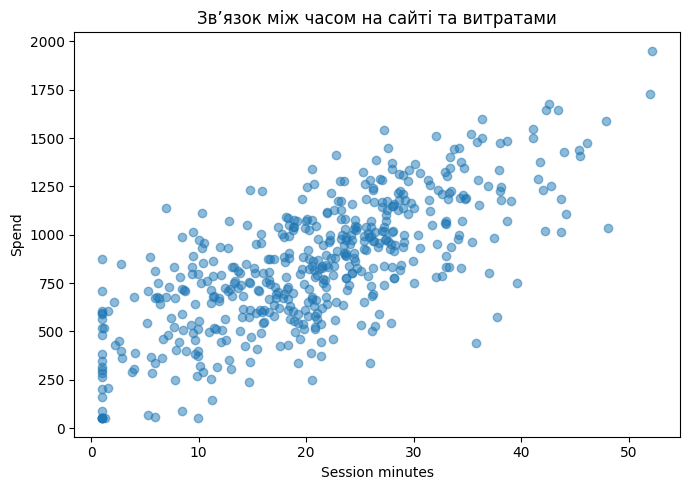

In [ ]:
# Завдання 12:
# 1.Кореляція Пірсона
from scipy.stats import pearsonr

# Видаляємо пропуски
temp = df[['session_min', 'spend']].dropna()

# Кореляція Пірсона
r, p_value = pearsonr(temp['session_min'], temp['spend'])

print(f'Кореляція (r): {r:.4f}')
print(f'p-значення: {p_value:.4f}')

# 2.Scatter plot (діаграма розсіювання)

plt.figure(figsize=(7,5))
plt.scatter(temp['session_min'], temp['spend'], alpha=0.5)

plt.title('Зв’язок між часом на сайті та витратами')
plt.xlabel('Session minutes')
plt.ylabel('Spend')

plt.tight_layout()
plt.show()

#### 💬 Інтерпретація 10

Опишіть звʼязок: він прямий чи зворотний? Сильний чи слабкий? Значущий? І найголовніше: чи можна стверджувати, що довший час на сайті СПРИЧИНЯЄ більші витрати? Поясніть свою думку.

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**
Напрямок: прямий (позитивний)
 -> чим довше користувач перебуває на сайті, тим вищі його витрати
Сила зв’язку: сильна -> значення 0.73 зазвичай інтерпретується як сильна позитивна кореляція
Статистична значущість: так
-> p-value < 0.05, отже зв’язок статистично значущий
Дані показують, що користувачі, які довше перебувають на сайті, зазвичай витрачають більше, але це не означає, що збільшення часу автоматично підвищить виторг.
Навіть сильна та значуща кореляція не доводить причинно-наслідковий зв’язок, тому що:

може існувати третій фактор (наприклад, інтерес до товарів, тип клієнта, сезонність)
користувачі, які і так планують купити більше, просто проводять більше часу
можлива зворотна причинність або змішаний ефект.

**Сценарій:** чи повʼязаний вік клієнта (`age`) з його витратами (`spend`)?

#### ✏️ Завдання 13 (код)

Порахуйте кореляцію між `age` та `spend`.

In [ ]:
# Завдання 13:from scipy.stats import pearsonr

# Прибираємо пропуски
temp = df[['age', 'spend']].dropna()

# Кореляція Пірсона
r, p_value = pearsonr(temp['age'], temp['spend'])

print(f'Кореляція (r): {r:.4f}')
print(f'p-значення: {p_value:.4f}')

Кореляція (r): -0.0418
p-значення: 0.3508


#### 💬 Інтерпретація 11

Що показала кореляція? Порівняйте цей результат із попереднім (час на сайті vs витрати). У якому випадку звʼязок сильніший і чому це важливо для бізнесу?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

Результати кореляційного аналізу показали, що між віком клієнта  і витратами  існує майже відсутній зв’язок: r = -0.0418, а p-value = 0.3508.
| Зв’язок             | r         | Сила      |
| ------------------- | --------- | --------- |
| session_min ↔ spend | **0.73**  | сильний   |
| age ↔ spend         | **-0.04** | відсутній |

Отже, набагато сильніший зв’язок був між часом на сайті та витратами, а не між віком і витратами.

Для бізнесу важливо не просто знати демографію клієнтів, а розуміти їх поведінку. У цьому випадку поведінковий фактор (час на сайті) значно інформативніший за демографічний (вік).

---
# Розділ 7. 🔥 Велике завдання: A/B-тест

## 🟦 Теорія: A/B-тестування

Це головне застосування статистики в аналітиці. Ми порівнюємо дві версії (A — контроль, B — варіант) і перевіряємо, чи нова версія справді краща, чи різниця випадкова.

Оскільки результат тут — **категоріальний** (конвертувався / ні), ми використовуємо **хі-квадрат** на таблиці спряженості «група × конверсія».

**Дані `ab_test.csv`:**
- `session_id` — ID сесії
- `group` — A (стара версія) або B (нова версія)
- `converted` — 1 (купив) або 0 (не купив)

Це повноцінне завдання, що імітує реальну роботу аналітика. Виконуйте крок за кроком.

**Крок 1. Дослідіть дані.**

#### ✏️ Завдання 14 (код)

Подивіться на дані `ab`: скільки сесій у групі A і скільки в групі B? (підказка: `value_counts` на `group`)

In [ ]:
# Завдання 14:
# Кількість сесій у кожній групі
df = pd.read_csv('ab_test.csv')
df['group'].value_counts()


,count
group,
A,4000
B,4000


**Крок 2. Порахуйте конверсію кожної групи.**

Конверсія = частка тих, хто купив = середнє значення стовпця `converted` (бо це 0 і 1).

#### ✏️ Завдання 15 (код)

Порахуйте конверсію (середнє `converted`) для групи A і для групи B окремо. (Підказка: `ab.groupby('group')['converted'].mean()`) На скільки відсоткових пунктів відрізняється конверсія?

In [ ]:
# Завдання 15:
# Конверсія по кожній групі
conversion_rate = df.groupby('group')['converted'].mean()

print('Конверсія по групах:')
print(conversion_rate)

Конверсія по групах:
group
A    0.101
B    0.119
Name: converted, dtype: float64


#### 💬 Інтерпретація 12

Яка група показує вищу конверсію? Чи означає ця різниця в числах, що версія B точно краща? Чому ми НЕ можемо зробити висновок лише з цих чисел, без статистичного тесту?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

Група B має вищу конверсію +0.018 = +1.8 процентних пункти.

Чи означає це, що B точно краща?

 Ні — не можна так стверджувати лише з цих чисел.

 Хоча група B показує вищу конверсію (11.9% vs 10.1%), це ще не доводить, що нова версія сайту краща. Для цього потрібно провести статистичний тест, який перевірить, чи є ця різниця значущою, а не випадковою.

**Крок 3. Сформулюйте гіпотези.**

#### 💬 Інтерпретація 13

Запишіть нульову (H₀) та альтернативну (H₁) гіпотези для цього A/B-тесту своїми словами.

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

Нульова гіпотеза (H₀):
Конверсія в групі A (стара версія сайту) і групі B (нова версія сайту) однакова. Тобто зміна дизайну не вплинула на ймовірність покупки.

Альтернативна гіпотеза (H₁):
Конверсія в групі B відрізняється від конверсії в групі A. Тобто нова версія сайту впливає на поведінку користувачів і змінює ймовірність покупки.

**Крок 4. Проведіть тест.**

#### ✏️ Завдання 16 (код)

Побудуйте таблицю спряженості `group` × `converted` і проведіть тест хі-квадрат. Виведіть таблицю та p-значення.

In [ ]:
# Завдання 16:


**Крок 5. Висновок.**

#### 💬 Інтерпретація 14

На основі p-значення: чи є різниця між версіями статистично значущою (при α = 0.05)? Який ваш висновок — впроваджувати версію B чи ні? Сформулюйте фінальну рекомендацію для продуктової команди одним абзацом, як справжній аналітик.

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

*...*

---
# Розділ 8. 🧠 Обери тест сам

## 🟦 Теорія

Найважливіша навичка аналітика — не запам'ятати функції, а вміти **обрати правильний тест** для задачі. У цьому розділі ми НЕ підказуємо тест — ви маєте визначити його самі.

**Алгоритм вибору:**
1. Який тип даних на виході? (числовий чи категоріальний)
2. Скільки груп / змінних порівнюємо?
3. Це незалежні групи чи «до/після» в тих самих об'єктів?

Кожне завдання: спочатку у клітинці інтерпретації **назвіть тест і поясніть вибір**, потім напишіть код.

**Задача A.** Компанія хоче знати, чи відрізняється середній вік клієнтів у трьох каналах залучення.

#### 💬 Інтерпретація 15

Який тест ви оберете і чому? (Спочатку відповідь, потім код нижче.)

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

*...*

#### ✏️ Завдання 17 (код)

Проведіть обраний тест для задачі A (вік за каналами).

In [ ]:
# Завдання 17:


#### 💬 Інтерпретація 16

Що показав результат? Сформулюйте висновок.

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

*...*

**Задача B.** Маркетолог стверджує, що середні витрати клієнтів дорівнюють 900 грн.

#### 💬 Інтерпретація 17

Який тест підходить і чому?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

*...*

#### ✏️ Завдання 18 (код)

Проведіть обраний тест для задачі B.

In [ ]:
# Завдання 18:


#### 💬 Інтерпретація 18

Висновок: маркетолог має рацію?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

*...*

**Задача C.** Чи повʼязана країна клієнта (`country`) з пристроєм (`device`)?

#### 💬 Інтерпретація 19

Який тест підходить і чому?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

*...*

#### ✏️ Завдання 19 (код)

Проведіть обраний тест для задачі C.

In [ ]:
# Завдання 19:


#### 💬 Інтерпретація 20

Висновок про звʼязок країни та пристрою.

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

*...*

**Задача D.** Чи повʼязаний вік клієнта з часом, який він проводить на сайті?

#### 💬 Інтерпретація 21

Який тест підходить і чому?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

*...*

#### ✏️ Завдання 20 (код)

Проведіть обраний тест для задачі D.

In [ ]:
# Завдання 20:


#### 💬 Інтерпретація 22

Опишіть звʼязок (напрямок, сила, значущість).

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

*...*

---
# 🎉 Вітаємо із завершенням!

Ви пройшли повний цикл роботи аналітика зі статистичними тестами:

- ✅ Одновибірковий, двовибірковий та парний t-тести
- ✅ ANOVA для 3+ груп
- ✅ Хі-квадрат для категоріальних даних
- ✅ Кореляція для числових змінних
- ✅ Повноцінний A/B-тест
- ✅ Самостійний вибір тесту під задачу

## Головне, що варто винести

1. **Вибір тесту** важливіший за код. Завжди питайте: який тип даних? скільки груп? незалежні чи парні?
2. **p-значення** саме по собі — це лише число. Цінність створює ваша **інтерпретація**.
3. **Контекст вирішує:** памʼятайте про розмір ефекту, практичну значущість і те, що кореляція ≠ причинність.

## Питання для самоперевірки
- Чи можете ви пояснити різницю між парним і двовибірковим t-тестом?
- Чому не можна замінити одну ANOVA трьома t-тестами?
- Що означає «не відхилили H₀» — чи це те саме, що «довели, що ефекту немає»?

Якщо на всі три питання ви відповідаєте впевнено — ви добре засвоїли тему. Так тримати! 📊
